In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid')
print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


In [2]:
df = pd.read_csv("real_estate_data.csv", low_memory=False)
print("Датасет успешно загружен.")

Датасет успешно загружен.


In [3]:
# ============ СЛОВАРИ ПЕРЕВОДА (турецкий → русский) ============
type_map = {
    "Konut": "Жильё",
}

sub_type_map = {
    "Rezidans": "Резиденция",
    "Daire": "Квартира",
    "Villa": "Вилла",
    "Müstakil Ev": "Отдельный дом",
    "Yazlık": "Дача",
    "Prefabrik Ev": "Сборный дом",
    "Kooperatif": "Кооператив",
    "Komple Bina": "Целое здание",
    "Köşk / Konak / Yalı": "Особняк / Усадьба / Дом у воды",
    "Çiftlik Evi": "Фермерский дом",
    "Yalı Dairesi": "Квартира у воды",
    "Loft": "Лофт",
    "Köy Evi": "Сельский дом",
}

listing_type_map = {
    "1": "Продажа",
    "2": "Аренда",
    "3": "Аренда на день",
}

heating_map = {
    "Fancoil": "Фанкойл",
    "Kalorifer (Doğalgaz)": "Центральное (газ)",
    "Yok": "Нет",
}

furnished_map = {
    "": "Нет",
    "Yok": "Нет",
}

# Перевод названий городов (турецкий → русский)
city_map = {
    "İstanbul": "Стамбул",
    "Ankara": "Анкара",
    "İzmir": "Измир",
    "Bursa": "Бурса",
    "Antalya": "Анталья",
    "Adana": "Адана",
    "Konya": "Конья",
    "Gaziantep": "Газиантеп",
    "Mersin": "Мерсин",
    "Kayseri": "Кайсери",
    "Eskişehir": "Эскишехир",
    "Samsun": "Самсун",
    "Denizli": "Денизли",
    "Şanlıurfa": "Шанлыурфа",
    "Malatya": "Малатья",
    "Kahramanmaraş": "Кахраманмараш",
    "Erzurum": "Эрзурум",
    "Van": "Ван",
    "Diyarbakır": "Диярбакыр",
    "Trabzon": "Трабзон",
    "Sakarya": "Сакарья",
    "Kocaeli": "Коджаэли",
    "Balıkesir": "Балыкесир",
    "Manisa": "Маниса",
    "Aydın": "Айдын",
    "Muğla": "Мугла",
    "Tekirdağ": "Текирдаг",
    "Çanakkale": "Чанаккале",
    "Edirne": "Эдирне",
    "Kırklareli": "Кыркларели",
    "Yalova": "Ялова",
    "Bilecik": "Биледжик",
    "Bolu": "Болу",
    "Düzce": "Дюздже",
    "Zonguldak": "Зонгулдак",
    "Karabük": "Карабюк",
    "Kastamonu": "Кастамону",
    "Sinop": "Синоп",
    "Ordu": "Орду",
    "Giresun": "Гиресун",
    "Rize": "Ризе",
    "Artvin": "Артвин",
    "Erzincan": "Эрзинджан",
    "Sivas": "Сивас",
    "Yozgat": "Йозгат",
    "Kırşehir": "Кыршехир",
    "Nevşehir": "Невшехир",
    "Niğde": "Нигде",
    "Aksaray": "Аксарай",
    "Karaman": "Караман",
    "Kırıkkale": "Кырыккале",
    "Çankırı": "Чанкыры",
    "Amasya": "Амасья",
    "Tokat": "Токат",
    "Çorum": "Чорум",
    "Kütahya": "Кютахья",
    "Afyonkarahisar": "Афьонкарахисар",
    "Uşak": "Ушак",
    "Isparta": "Ыспарта",
    "Burdur": "Бурдур",
    "Osmaniye": "Османие",
    "Hatay": "Хатай",
    "Kilis": "Килис",
    "Mardin": "Мардин",
    "Batman": "Батман",
    "Siirt": "Сиирт",
    "Şırnak": "Шырнак",
    "Bitlis": "Битлис",
    "Muş": "Муш",
    "Ağrı": "Агры",
    "Iğdır": "Ыгдыр",
    "Kars": "Карс",
    "Ardahan": "Ардахан",
    "Bayburt": "Байбурт",
    "Gümüşhane": "Гюмюшхане",
    "Tunceli": "Тунджели",
    "Elazığ": "Элязыг",
    "Bingöl": "Бингёль",
    "Adıyaman": "Адыяман",
    "KKTC": "ТРСК",
}

print("Словари перевода загружены.")

Словари перевода загружены.


In [4]:
# ============ ПЕРЕВОД КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ ============
if "type" in df.columns:
    df["type"] = df["type"].map(lambda x: type_map.get(x, x))

if "sub_type" in df.columns:
    df["sub_type"] = df["sub_type"].map(lambda x: sub_type_map.get(x, x))

if "listing_type" in df.columns:
    # значения хранятся как числа (1, 2, 3) — приводим к строке для сопоставления со словарём
    df["listing_type"] = df["listing_type"].astype(str).map(lambda x: listing_type_map.get(x, x))

if "heating_type" in df.columns:
    df["heating_type"] = df["heating_type"].map(lambda x: heating_map.get(x, x))

if "furnished" in df.columns:
    df["furnished"] = df["furnished"].map(lambda x: furnished_map.get(x, x))

print("Категориальные признаки переведены на русский.")
df[["type", "sub_type", "listing_type", "heating_type"]].head()

Категориальные признаки переведены на русский.


,type,sub_type,listing_type,heating_type
0,Жильё,Резиденция,Аренда,Фанкойл
1,Жильё,Квартира,Продажа,Фанкойл
2,Жильё,Квартира,Продажа,Фанкойл
3,Жильё,Резиденция,Продажа,Фанкойл
4,Жильё,Резиденция,Продажа,Фанкойл


In [5]:
rows, columns = df.shape

print(f"Количество строк: {rows:,}")
print(f"Количество столбцов: {columns}")

Количество строк: 403,487
Количество столбцов: 17


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  str    
 2   sub_type           403487 non-null  str    
 3   start_date         403487 non-null  str    
 4   end_date           266298 non-null  str    
 5   listing_type       403487 non-null  str    
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  str    
 8   total_floor_count  375466 non-null  str    
 9   floor_no           368191 non-null  str    
 10  room_count         403487 non-null  str    
 11  size               257481 non-null  float64
 12  address            403487 non-null  str    
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  str    
 15  price              402772 non-null  float64
 16  price_currenc

In [7]:
columns_info = pd.DataFrame({
    'Столбец': df.columns,
    'Тип данных': df.dtypes.astype(str).values,
    'Количество непустых': df.notna().sum().values,
    'Пропущено': df.isna().sum().values,
    'Уникальных значений': df.nunique(dropna=True).values
})

columns_info

,Столбец,Тип данных,Количество непустых,Пропущено,Уникальных значений
0,id,int64,403487,0,403487
1,type,str,403487,0,1
2,sub_type,str,403487,0,12
3,start_date,str,403487,0,181
4,end_date,str,266298,137189,181
5,listing_type,str,403487,0,3
6,tom,int64,403487,0,181
7,building_age,str,376097,27390,14
8,total_floor_count,str,375466,28021,12
9,floor_no,str,368191,35296,35


In [8]:
description = pd.DataFrame({
    'Признак': [
        'id',
        'type',
        'sub_type',
        'start_date',
        'end_date',
        'listing_type',
        'tom',
        'building_age',
        'total_floor_count',
        'floor_no',
        'room_count',
        'size',
        'address',
        'furnished',
        'heating_type',
        'price',
        'price_currency'
    ],
    'Описание': [
        'Уникальный идентификатор объявления',
        'Тип объекта недвижимости',
        'Подтип объекта недвижимости',
        'Дата начала публикации объявления',
        'Дата окончания публикации объявления',
        'Тип объявления',
        'Срок/период, связанный с объявлением',
        'Возраст здания или категория возраста',
        'Общее количество этажей',
        'Этаж расположения объекта',
        'Количество комнат',
        'Площадь объекта',
        'Адрес объекта',
        'Признак меблировки',
        'Тип отопления',
        'Цена объекта — целевая переменная',
        'Валюта цены'
    ]
})

description

,Признак,Описание
0,id,Уникальный идентификатор объявления
1,type,Тип объекта недвижимости
2,sub_type,Подтип объекта недвижимости
3,start_date,Дата начала публикации объявления
4,end_date,Дата окончания публикации объявления
5,listing_type,Тип объявления
6,tom,"Срок/период, связанный с объявлением"
7,building_age,Возраст здания или категория возраста
8,total_floor_count,Общее количество этажей
9,floor_no,Этаж расположения объекта


In [9]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Жильё,Резиденция,12/10/18,1/9/19,Аренда,30,0,20 ve üzeri,2,2+1,90.00,İstanbul/Kartal/Kordonboyu,NaN,Фанкойл,"3,500.00",TRY
1,2,Жильё,Квартира,2/13/19,NaN,Продажа,14,0,20 ve üzeri,20 ve üzeri,1+0,43.00,İstanbul/Kartal/Kordonboyu,NaN,Фанкойл,"490,000.00",TRY
2,3,Жильё,Квартира,10/9/18,11/8/18,Продажа,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Фанкойл,"155,000.00",TRY
3,4,Жильё,Резиденция,9/10/18,10/10/18,Продажа,30,3,20 ve üzeri,20 ve üzeri,6+1,450.00,İstanbul/Beşiktaş/Levent,NaN,Фанкойл,"32,500,000.00",TRY
4,5,Жильё,Резиденция,12/10/18,1/9/19,Продажа,30,0,20 ve üzeri,2,2+1,90.00,İstanbul/Kartal/Kordonboyu,NaN,Фанкойл,"1,450,000.00",TRY


In [10]:
df.tail()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Жильё,Квартира,9/18/18,NaN,Аренда,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,"1,500.00",TRY
403483,403484,Жильё,Квартира,10/11/18,NaN,Продажа,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,"120,000.00",TRY
403484,403485,Жильё,Квартира,11/22/18,NaN,Продажа,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,"48,000.00",EUR
403485,403486,Жильё,Квартира,2/21/19,NaN,Аренда,6,NaN,NaN,NaN,2+1,2.00,Aydın/Kuşadası/Türkmen,NaN,NaN,900.00,TRY
403486,403487,Жильё,Квартира,1/15/19,1/18/19,Продажа,3,NaN,NaN,NaN,3+1,140.00,Kayseri/Melikgazi/Alpaslan,NaN,NaN,"210,000.00",TRY


In [11]:
df.sample(1, random_state=42)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,60624,Жильё,Квартира,11/20/18,2/23/19,Продажа,95,6-10 arası,5,1,2+1,120.00,Antalya/Alanya/Oba,NaN,Klima,"240,000.00",TRY


In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Числовые признаки:")
print(numeric_columns)

print("\nКатегориальные/текстовые признаки:")
print(categorical_columns)

Числовые признаки:
['id', 'tom', 'size', 'furnished', 'price']

Категориальные/текстовые признаки:
['type', 'sub_type', 'start_date', 'end_date', 'listing_type', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'address', 'heating_type', 'price_currency']


C:\Users\sondi\AppData\Local\Temp\ipykernel_13168\1249028546.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns.tolist()


In [13]:
numeric_stats = pd.DataFrame({
    'Минимум': df[numeric_columns].min(),
    'Q1 (25%)': df[numeric_columns].quantile(0.25),
    'Медиана': df[numeric_columns].median(),
    'Среднее': df[numeric_columns].mean(),
    'Q3 (75%)': df[numeric_columns].quantile(0.75),
    'Максимум': df[numeric_columns].max(),
    'Стандартное отклонение': df[numeric_columns].std()
})

numeric_stats

,Минимум,Q1 (25%),Медиана,Среднее,Q3 (75%),Максимум,Стандартное отклонение
id,1.00,"100,872.50","201,744.00","201,744.00","302,615.50","403,487.00","116,476.81"
tom,0.00,29.00,40.00,57.02,90.00,180.00,44.36
size,1.00,85.00,110.00,279.35,140.00,"948,235.00","9,429.20"
furnished,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,-250.00,"2,500.00","199,000.00","354,641.66","342,000.00","2,000,000,000.00","4,809,502.70"


In [14]:
skewness = df[numeric_columns].skew().sort_values(ascending=False)

skewness.to_frame(name='Коэффициент асимметрии')

,Коэффициент асимметрии
price,308.51
size,77.65
tom,0.84
id,0.00
furnished,NaN


In [15]:
categorical_stats = pd.DataFrame({
    'Количество уникальных': df[categorical_columns].nunique(dropna=True),
    'Пропущено': df[categorical_columns].isna().sum(),
    'Самая частая категория': [
        df[col].mode(dropna=True).iloc[0] if not df[col].mode(dropna=True).empty else np.nan
        for col in categorical_columns
    ],
    'Частота самой частой категории': [
        df[col].value_counts(dropna=True).iloc[0] if df[col].notna().any() else 0
        for col in categorical_columns
    ]
})

categorical_stats

,Количество уникальных,Пропущено,Самая частая категория,Частота самой частой категории
type,1,0,Жильё,403487
sub_type,12,0,Квартира,354549
start_date,181,0,10/11/18,4064
end_date,181,137189,12/19/18,3048
listing_type,3,0,Продажа,287009
building_age,14,27390,0,140174
total_floor_count,12,28021,4,83082
floor_no,35,35296,2,65864
room_count,37,0,3+1,157363
address,7842,0,Balıkesir/Edremit/Akçay,5611


In [16]:
for column in ['type', 'sub_type', 'heating_type', 'price_currency']:
    print(f"\n{'='*60}")
    print(f"Признак: {column}")
    print(df[column].value_counts(dropna=False).head(20))


Признак: type
type
Жильё    403487
Name: count, dtype: int64

Признак: sub_type
sub_type
Квартира                          354549
Вилла                              21324
Отдельный дом                       9563
Резиденция                          7716
Дача                                5929
Целое здание                        2607
Сборный дом                          679
Фермерский дом                       528
Особняк / Усадьба / Дом у воды       301
Квартира у воды                      187
Кооператив                            70
Лофт                                  34
Name: count, dtype: int64

Признак: heating_type
heating_type
Kombi (Doğalgaz)                   204150
Klima                               68197
Merkezi Sistem (Isı Payı Ölçer)     30595
NaN                                 27970
Merkezi Sistem                      22855
Центральное (газ)                   10928
Soba (Kömür)                         8450
Yerden Isıtma                        6958
Нет                 

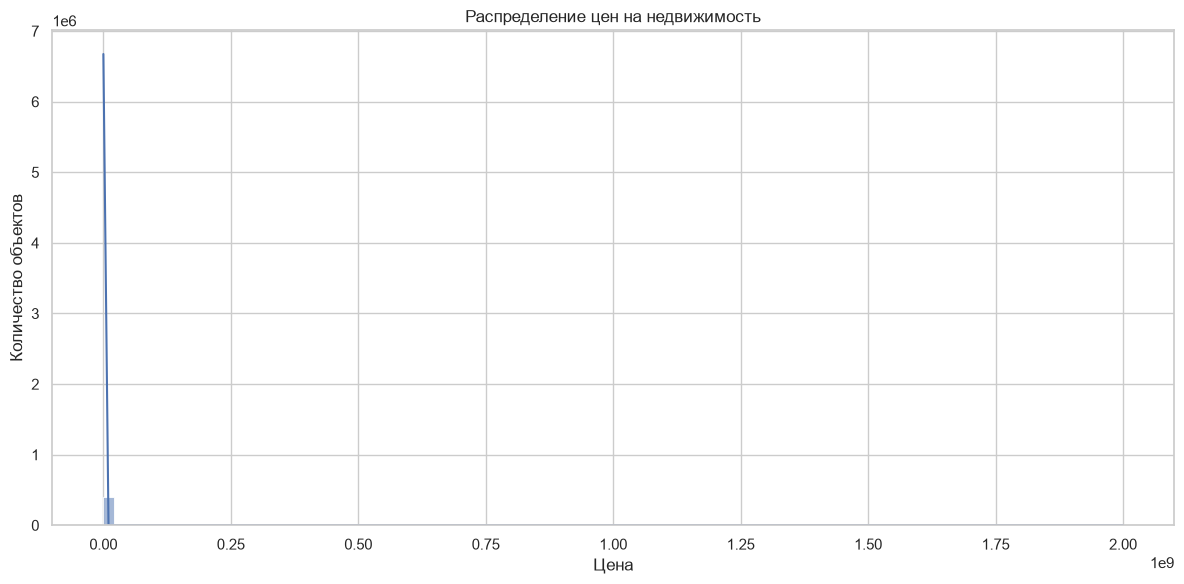

In [17]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='price',
    bins=100,
    kde=True
)

plt.title('Распределение цен на недвижимость')
plt.xlabel('Цена')
plt.ylabel('Количество объектов')
plt.tight_layout()
plt.show()

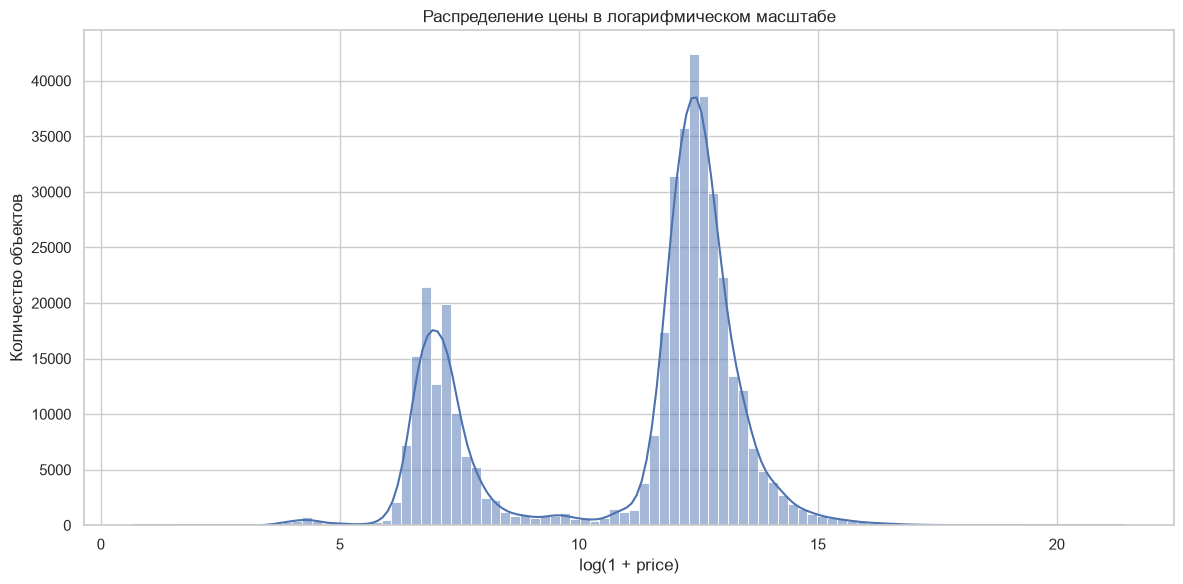

In [18]:
positive_price = df.loc[df['price'] > 0, 'price']

plt.figure(figsize=(12, 6))

sns.histplot(
    np.log1p(positive_price),
    bins=100,
    kde=True
)

plt.title('Распределение цены в логарифмическом масштабе')
plt.xlabel('log(1 + price)')
plt.ylabel('Количество объектов')
plt.tight_layout()
plt.show()

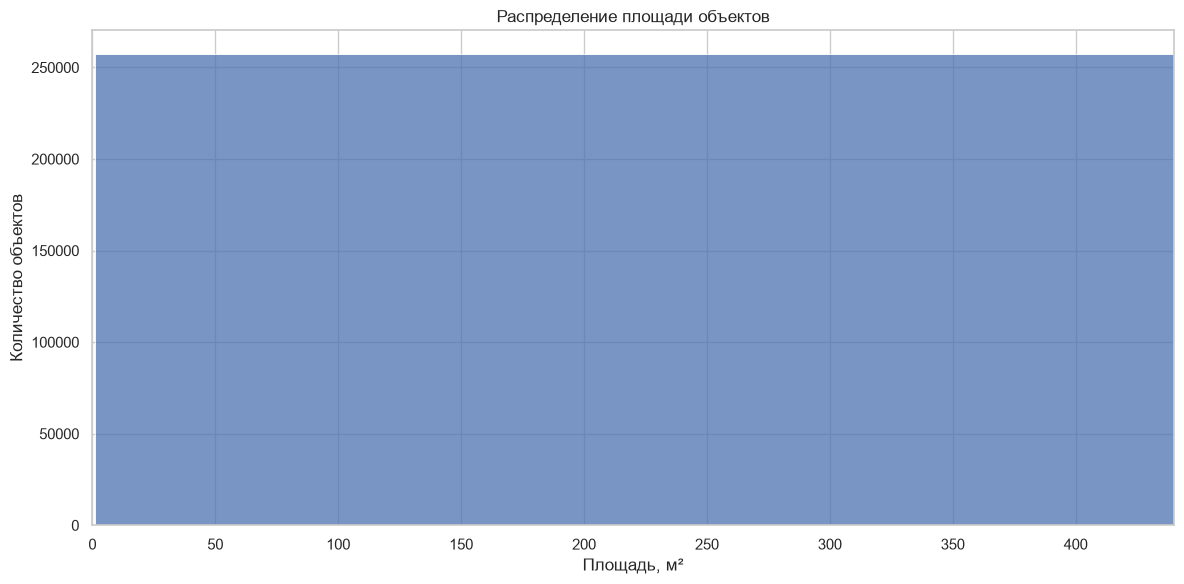

In [19]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='size',
    bins=100
)

plt.title('Распределение площади объектов')
plt.xlabel('Площадь, м²')
plt.ylabel('Количество объектов')
plt.xlim(0, df['size'].quantile(0.99))

plt.tight_layout()
plt.show()

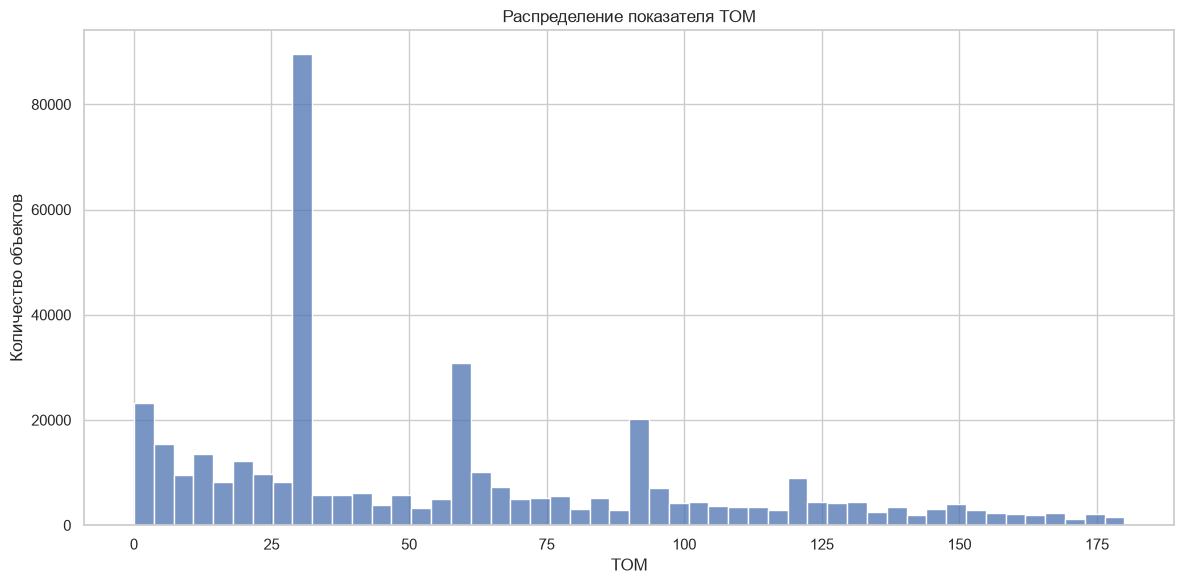

In [20]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='tom',
    bins=50
)

plt.title('Распределение показателя TOM')
plt.xlabel('TOM')
plt.ylabel('Количество объектов')

plt.tight_layout()
plt.show()

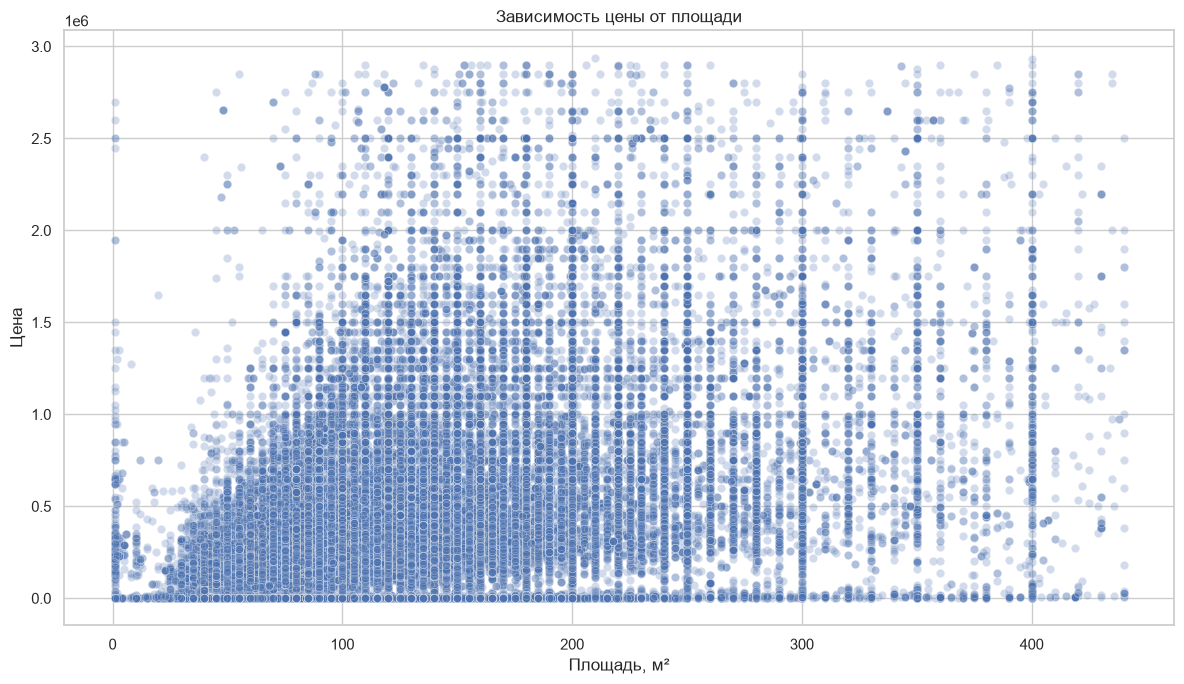

In [21]:
scatter_data = df[
    (df['price'] > 0) &
    (df['size'] > 0)
].copy()

price_limit = scatter_data['price'].quantile(0.99)
size_limit = scatter_data['size'].quantile(0.99)

scatter_data = scatter_data[
    (scatter_data['price'] <= price_limit) &
    (scatter_data['size'] <= size_limit)
]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=scatter_data,
    x='size',
    y='price',
    alpha=0.25
)

plt.title('Зависимость цены от площади')
plt.xlabel('Площадь, м²')
plt.ylabel('Цена')

plt.tight_layout()
plt.show()

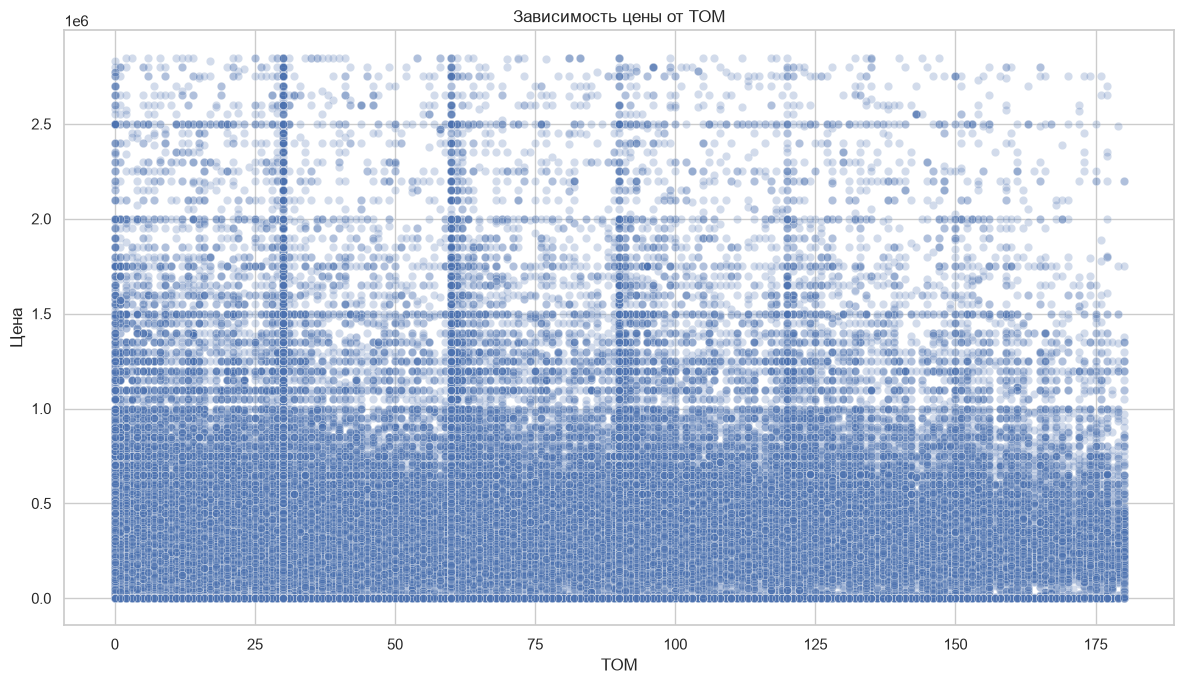

In [22]:
scatter_data = df[df['price'] > 0].copy()

price_limit = scatter_data['price'].quantile(0.99)

scatter_data = scatter_data[
    scatter_data['price'] <= price_limit
]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=scatter_data,
    x='tom',
    y='price',
    alpha=0.25
)

plt.title('Зависимость цены от TOM')
plt.xlabel('TOM')
plt.ylabel('Цена')

plt.tight_layout()
plt.show()

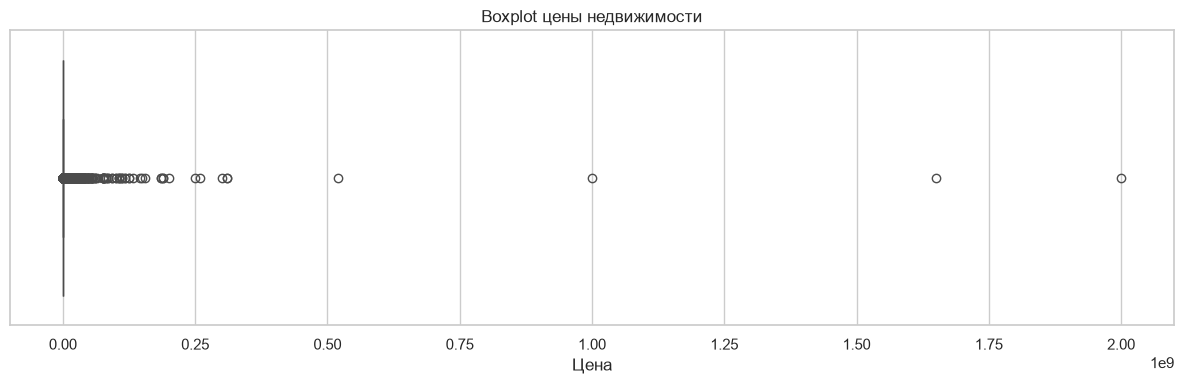

In [23]:
price_for_boxplot = df.loc[df['price'] > 0, 'price']

plt.figure(figsize=(12, 4))

sns.boxplot(
    x=price_for_boxplot
)

plt.title('Boxplot цены недвижимости')
plt.xlabel('Цена')

plt.tight_layout()
plt.show()

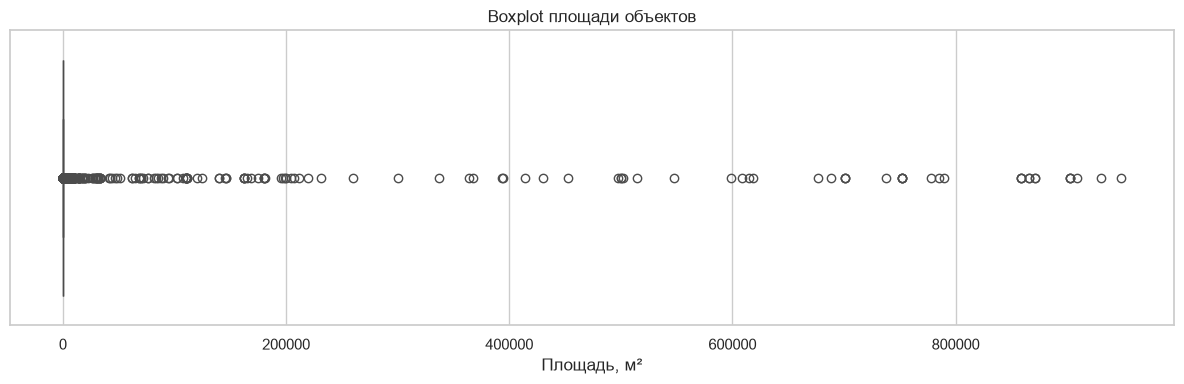

In [24]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df['size'].dropna()
)

plt.title('Boxplot площади объектов')
plt.xlabel('Площадь, м²')

plt.tight_layout()
plt.show()

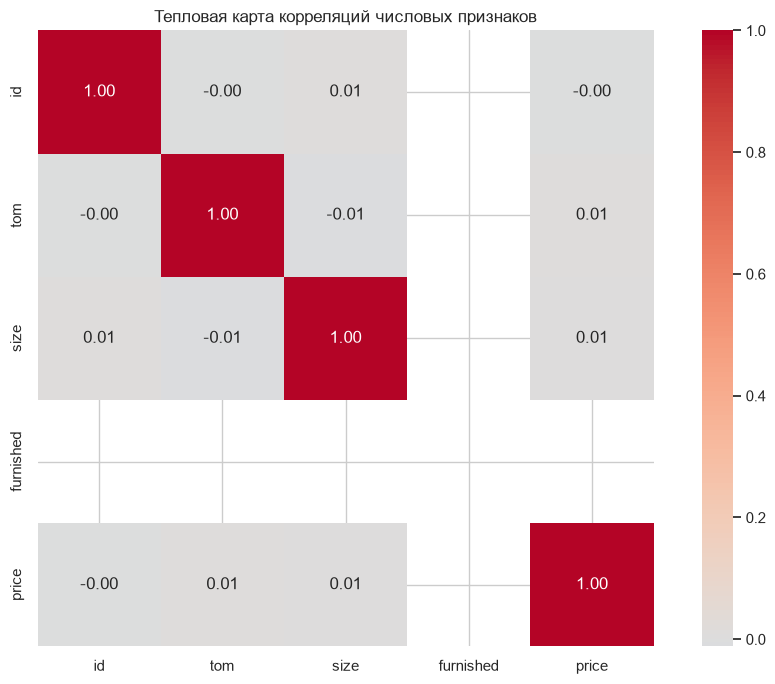

In [25]:
correlation_columns = [
    'id',
    'listing_type',
    'tom',
    'size',
    'furnished',
    'price'
]

corr = df[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Тепловая карта корреляций числовых признаков')
plt.tight_layout()
plt.show()

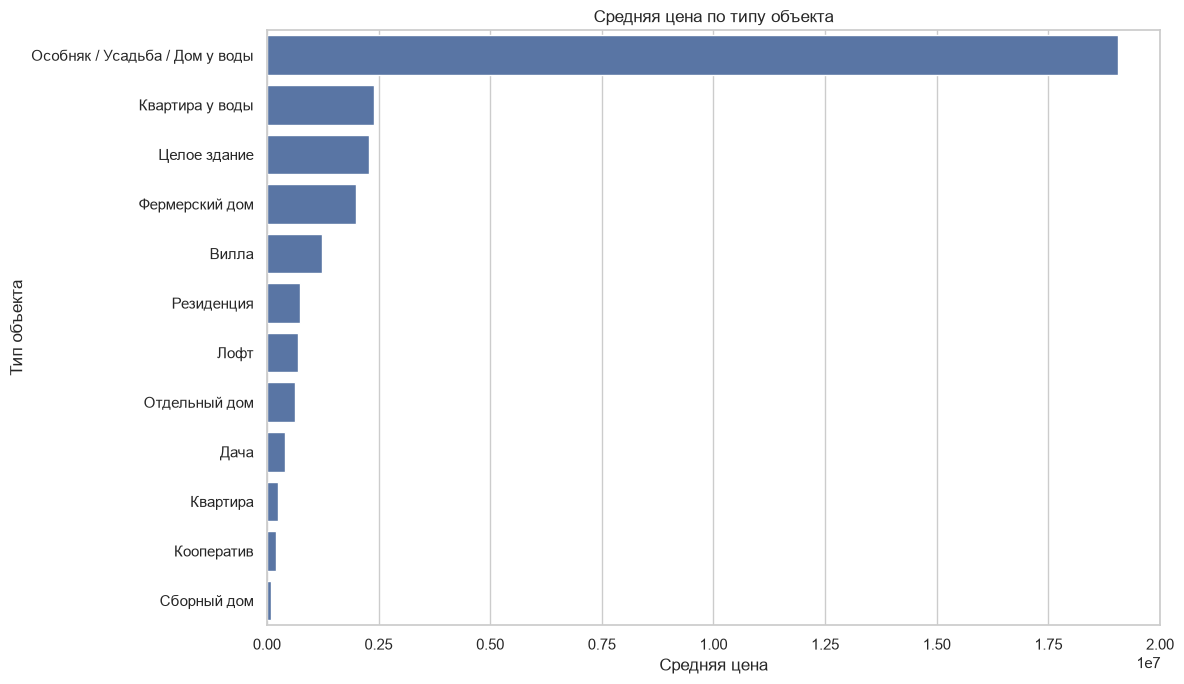

In [26]:
subtype_price = (
    df[df['price'] > 0]
    .groupby('sub_type')['price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subtype_price.values,
    y=subtype_price.index
)

plt.title('Средняя цена по типу объекта')
plt.xlabel('Средняя цена')
plt.ylabel('Тип объекта')

plt.tight_layout()
plt.show()

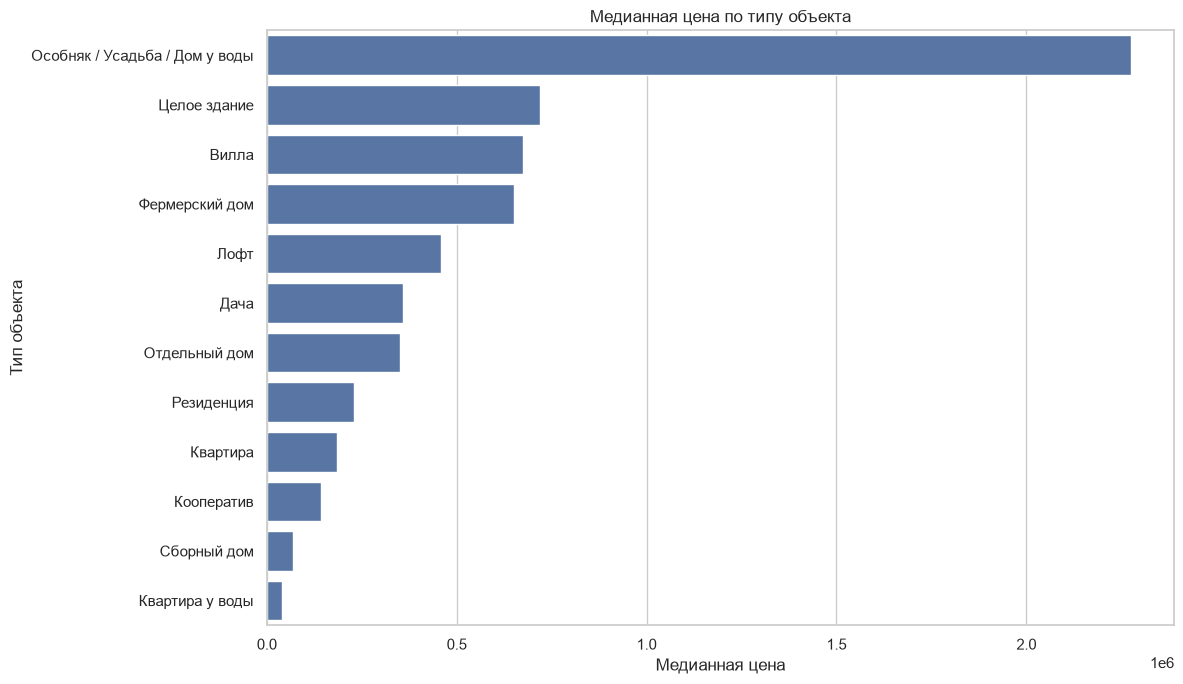

In [27]:
subtype_price_median = (
    df[df['price'] > 0]
    .groupby('sub_type')['price']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subtype_price_median.values,
    y=subtype_price_median.index
)

plt.title('Медианная цена по типу объекта')
plt.xlabel('Медианная цена')
plt.ylabel('Тип объекта')

plt.tight_layout()
plt.show()

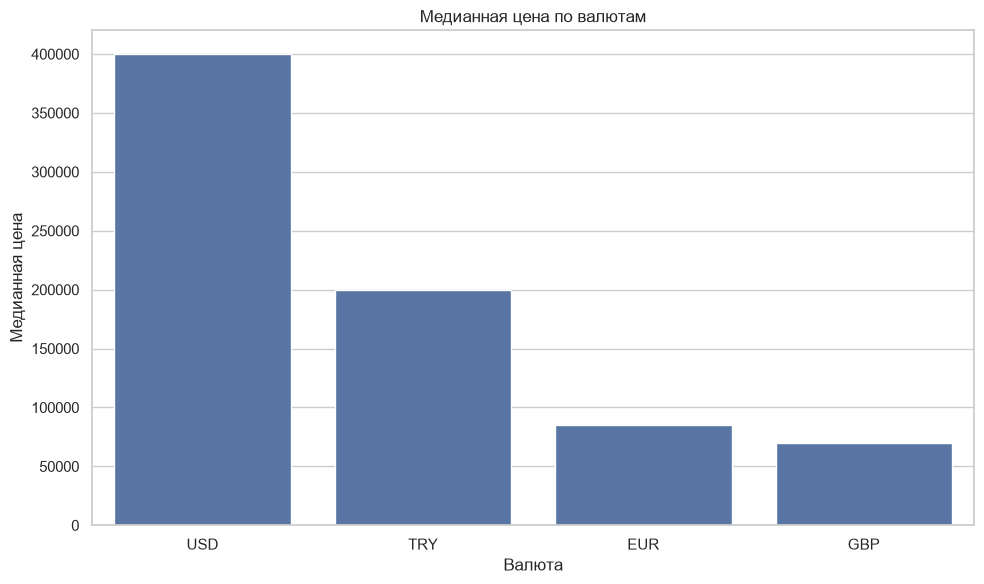

In [28]:
currency_price = (
    df[df['price'] > 0]
    .groupby('price_currency')['price']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=currency_price.index,
    y=currency_price.values
)

plt.title('Медианная цена по валютам')
plt.xlabel('Валюта')
plt.ylabel('Медианная цена')

plt.tight_layout()
plt.show()

In [29]:
missing = pd.DataFrame({
    'Пропущено': df.isna().sum(),
    'Доля пропусков, %': df.isna().mean() * 100
})

missing = missing.sort_values(
    by='Пропущено',
    ascending=False
)

missing

,Пропущено,"Доля пропусков, %"
furnished,403487,100.00
size,146006,36.19
end_date,137189,34.00
floor_no,35296,8.75
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
price_currency,715,0.18
price,715,0.18
id,0,0.00


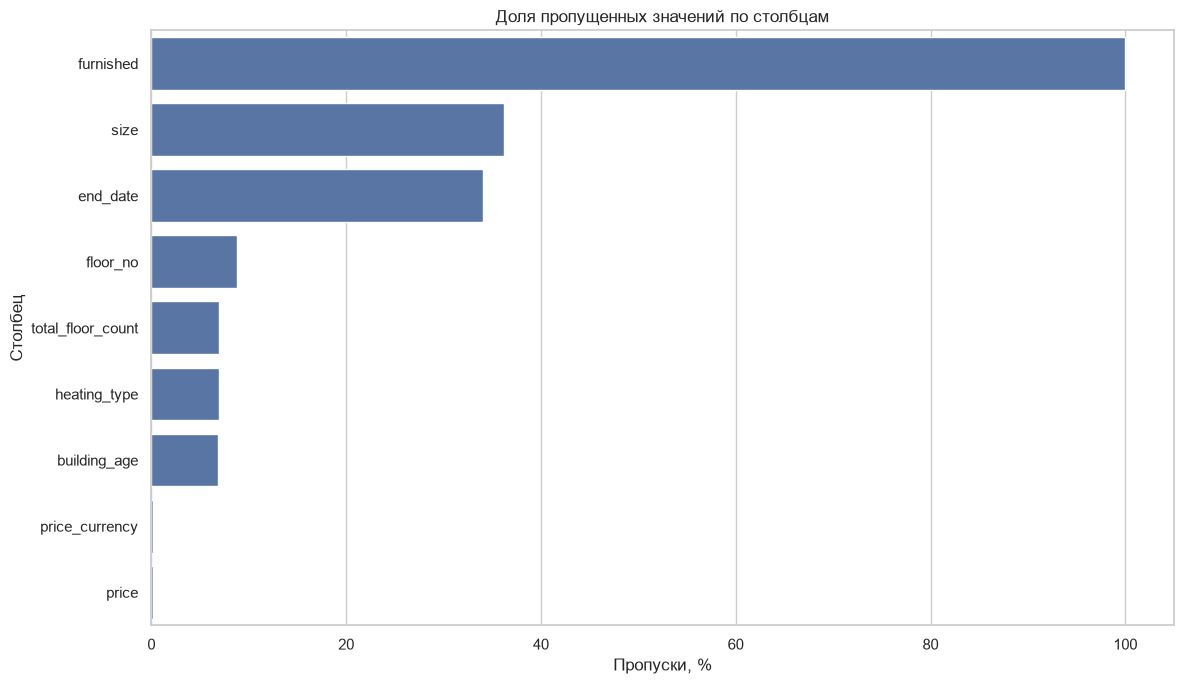

In [30]:
missing_plot = missing[missing['Пропущено'] > 0].copy()

plt.figure(figsize=(12, 7))

sns.barplot(
    x=missing_plot['Доля пропусков, %'],
    y=missing_plot.index
)

plt.title('Доля пропущенных значений по столбцам')
plt.xlabel('Пропуски, %')
plt.ylabel('Столбец')

plt.tight_layout()
plt.show()

In [31]:
duplicate_count = df.duplicated().sum()

print(f"Количество полных дубликатов: {duplicate_count}")

Количество полных дубликатов: 0


In [32]:
duplicate_ids = df['id'].duplicated().sum()

print(f"Повторяющихся ID: {duplicate_ids}")

Повторяющихся ID: 0


In [33]:
print("Количество отрицательных цен:",
      (df['price'] < 0).sum())

print("Количество нулевых цен:",
      (df['price'] == 0).sum())

print("Количество пропущенных цен:",
      df['price'].isna().sum())

Количество отрицательных цен: 1
Количество нулевых цен: 44
Количество пропущенных цен: 715


In [34]:
print("Пропуски площади:", df['size'].isna().sum())
print("Площадь <= 0:", (df['size'] <= 0).sum())
print("Максимальная площадь:", df['size'].max())

Пропуски площади: 146006
Площадь <= 0: 0
Максимальная площадь: 948235.0


In [35]:
size_threshold = df['size'].quantile(0.99)

large_size = df[df['size'] > size_threshold][
    ['id', 'sub_type', 'size', 'address', 'price', 'price_currency']
].sort_values('size', ascending=False)

large_size.head(20)

,id,sub_type,size,address,price,price_currency
126478,126479,Квартира,"948,235.00",Ankara/Elmadağ/Hasanoğlan Havuzbaşı,"311,222.00",USD
369219,369220,Квартира,"930,259.00",Ankara/Elmadağ/Hasanoğlan Havuzbaşı,"456,000.00",GBP
103042,103043,Резиденция,"909,039.00",İstanbul/Güngören/Tozkoparan,"943,213.00",TRY
367571,367572,Квартира,"902,221.00",Ankara/Altındağ/Altınpark,"7,824,233.00",USD
367824,367825,Квартира,"902,221.00",Ankara/Altındağ/Altınpark,"7,824,233.00",USD
368029,368030,Квартира,"902,221.00",Ankara/Altındağ/Altınpark,"7,824,233.00",USD
399426,399427,Квартира,"870,752.00",Manisa/Demirci/Akıncılar,"423,222.00",EUR
386661,386662,Квартира,"870,752.00",Manisa/Demirci/Akıncılar,"423,222.00",EUR
16968,16969,Квартира,"865,799.00",Ankara/Elmadağ/Yenimahalle,"219,222.00",TRY
16860,16861,Квартира,"865,799.00",Ankara/Elmadağ/Yenimahalle,"219,222.00",TRY


In [36]:
price_threshold = df['price'].quantile(0.99)

large_prices = df[df['price'] > price_threshold][
    ['id', 'sub_type', 'size', 'address', 'price', 'price_currency']
].sort_values('price', ascending=False)

large_prices.head(20)

,id,sub_type,size,address,price,price_currency
392156,392157,Квартира,NaN,Mersin/Toroslar/Mithat Toroğlu,"2,000,000,000.00",TRY
7435,7436,Особняк / Усадьба / Дом у воды,426.00,İstanbul/Beşiktaş/Bebek,"1,650,000,000.00",TRY
397627,397628,Квартира,160.00,Samsun/Atakum/Mevlana,"999,999,100.00",TRY
92930,92931,Квартира,130.00,İstanbul/Bağcılar/Merkez,"520,000,000.00",TRY
369884,369885,Особняк / Усадьба / Дом у воды,NaN,İstanbul/Üsküdar/Kandilli,"310,000,000.00",TRY
371170,371171,Особняк / Усадьба / Дом у воды,NaN,İstanbul/Üsküdar/Kandilli,"310,000,000.00",TRY
13209,13210,Квартира,130.00,İstanbul/Bağcılar/Merkez,"300,000,000.00",TRY
328479,328480,Целое здание,"28,323.00",İstanbul/Şişli/Mecidiyeköy,"260,000,000.00",TRY
103704,103705,Целое здание,NaN,Adana/Yumurtalık/Akyuva,"250,000,000.00",TRY
1319,1320,Целое здание,140.00,İstanbul/Fatih/Rüstem Paşa,"200,000,000.00",TRY


In [37]:
building_age_counts = (
    df['building_age']
    .value_counts(dropna=False)
)

building_age_counts

building_age
0              140174
6-10 arası      50495
11-15 arası     32309
16-20 arası     31333
NaN             27390
1               20355
4               19032
21-25 arası     18438
2               17466
3               15651
5               13589
26-30 arası     10581
31-35 arası      4268
36-40 arası      1347
40 ve üzeri      1059
Name: count, dtype: int64

In [38]:
floor_counts = (
    df['total_floor_count']
    .value_counts(dropna=False)
)

floor_counts

total_floor_count
4              83082
3              77956
5              70104
10-20 arası    36512
NaN            28021
2              27742
6              23348
10             12558
7              12284
8              11207
9               9029
20 ve üzeri     6679
1               4965
Name: count, dtype: int64

In [39]:
floor_no_counts = (
    df['floor_no']
    .value_counts(dropna=False)
)

floor_no_counts.head(30)

floor_no
2               65864
3               52690
1               46756
NaN             35296
4               34465
Yüksek Giriş    24045
5               21193
Müstakil        21165
Bahçe katı      19065
Giriş Katı      10431
6                9747
7                7698
8                6099
Kot 1            5036
Kot 2            4987
9                4855
10               3863
Kot 3            3793
Çatı Katı        3566
Zemin Kat        3441
Komple           2958
11               2894
12               2309
Kot 4            2269
13               1702
20 ve üzeri      1563
14               1328
15                911
En Üst Kat        894
Bodrum Kat        815
Name: count, dtype: int64

In [40]:
room_counts = (
    df['room_count']
    .value_counts(dropna=False)
)

room_counts.head(30)

room_count
3+1     157363
2+1     138677
1+1      39134
4+1      37472
5+1       8219
4+2       4540
5+2       2926
+         2898
3+2       2673
1+0       2612
6+1       2001
6+2       1517
2+2        836
7+1        523
7+2        428
10+0       313
8+1        218
8+2        189
6+3        167
5+3        139
4+3        133
7+3         86
9+1         71
9+3         65
9+2         61
8+3         55
8+4         38
10+1        35
10+2        30
9+5         27
Name: count, dtype: int64

In [41]:
print("ИТОГОВАЯ СВОДКА EDA")

print(f"\nРазмер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print(f"\nЦелевая переменная: price")
print(f"\nКоличество полных дубликатов: {df.duplicated().sum()}")
print("\nПропуски:")
print(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("\nОтрицательных цен:", (df['price'] < 0).sum())
print("Нулевых цен:", (df['price'] == 0).sum())

print("\nВалюты:")
print(df['price_currency'].value_counts(dropna=False))

print("\nТипы объектов:")
print(df['sub_type'].nunique())

print("\nМаксимальная площадь:", df['size'].max())
print("Максимальная цена:", df['price'].max())

ИТОГОВАЯ СВОДКА EDA

Размер датасета: 403,487 строк × 17 столбцов

Целевая переменная: price

Количество полных дубликатов: 0

Пропуски:
furnished            403487
size                 146006
end_date             137189
floor_no              35296
total_floor_count     28021
heating_type          27970
building_age          27390
price_currency          715
price                   715
id                        0
dtype: int64

Отрицательных цен: 1
Нулевых цен: 44

Валюты:
price_currency
TRY    400677
EUR       922
NaN       715
GBP       621
USD       552
Name: count, dtype: int64

Типы объектов:
12

Максимальная площадь: 948235.0
Максимальная цена: 2000000000.0


In [42]:
data = df.copy()

print(f"Исходный размер: {data.shape}")

Исходный размер: (403487, 17)


In [43]:
print("Пропущено price:", data['price'].isna().sum())
print("price <= 0:", (data['price'] <= 0).sum())

Пропущено price: 715
price <= 0: 45


In [44]:
data = data[data['price'].notna()].copy()

data = data[data['price'] > 0].copy()

print(f"Размер после очистки целевой переменной: {data.shape}")

Размер после очистки целевой переменной: (402727, 17)


In [45]:
empty_columns = [
    col for col in data.columns
    if data[col].isna().all()
]

print("Полностью пустые столбцы:")
print(empty_columns)

Полностью пустые столбцы:
['furnished']


In [46]:
data = data.drop(columns=empty_columns)

print("Размер после удаления пустых признаков:", data.shape)

Размер после удаления пустых признаков: (402727, 16)


In [47]:
data = data.drop(columns=['id'])

print("Столбец id удалён.")
print(data.columns.tolist())

Столбец id удалён.
['type', 'sub_type', 'start_date', 'end_date', 'listing_type', 'tom', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'size', 'address', 'heating_type', 'price', 'price_currency']


In [48]:
# Преобразование дат
data['start_date'] = pd.to_datetime(
    data['start_date'],
    errors='coerce'
)

data['end_date'] = pd.to_datetime(
    data['end_date'],
    errors='coerce'
)

print(data[['start_date', 'end_date']].dtypes)

start_date    datetime64[us]
end_date      datetime64[us]
dtype: object


C:\Users\sondi\AppData\Local\Temp\ipykernel_13168\1719010176.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['start_date'] = pd.to_datetime(
C:\Users\sondi\AppData\Local\Temp\ipykernel_13168\1719010176.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['end_date'] = pd.to_datetime(


In [49]:
# Новые признаки из даты публикации
data['start_year'] = data['start_date'].dt.year
data['start_month'] = data['start_date'].dt.month
data['start_dayofweek'] = data['start_date'].dt.dayofweek

# Продолжительность публикации объявления
data['listing_duration'] = (
    data['end_date'] - data['start_date']
).dt.days

# Удаляем исходные даты
data = data.drop(columns=['start_date', 'end_date'])

In [50]:
data[
    ['start_year', 'start_month', 'start_dayofweek', 'listing_duration']
].head()

,start_year,start_month,start_dayofweek,listing_duration
0,2018,12,0,30.00
1,2019,2,2,NaN
2,2018,10,1,30.00
3,2018,9,0,30.00
4,2018,12,0,30.00


In [51]:
# Разбираем адрес на составные части
address_parts = data['address'].str.split('/')

data['city'] = address_parts.str[0].map(lambda x: city_map.get(x, x))
data['district'] = address_parts.str[1]
data['neighborhood'] = address_parts.str[2]

# Удаляем исходный сложный адрес
data = data.drop(columns=['address'])

In [52]:
data[
    ['city', 'district', 'neighborhood']
].head()

,city,district,neighborhood
0,Стамбул,Kartal,Kordonboyu
1,Стамбул,Kartal,Kordonboyu
2,Текирдаг,Çorlu,Reşadiye
3,Стамбул,Beşiktaş,Levent
4,Стамбул,Kartal,Kordonboyu


In [53]:
def convert_building_age(value):
    """
    Преобразование категорий возраста здания
    в приблизительное числовое значение.
    """
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Обычное числовое значение
    try:
        return float(value)
    except ValueError:
        pass

    # Интервал вида 6-10 arası
    if '-' in value:
        try:
            numbers = value.split('-')
            left = float(numbers[0])
            right = float(numbers[1].split()[0])
            return (left + right) / 2
        except (ValueError, IndexError):
            return np.nan

    # 40 ve üzeri
    if '40' in value:
        return 40.0

    return np.nan

In [54]:
data['building_age'] = data['building_age'].apply(
    convert_building_age
)

data['building_age'].describe()

count   375,756.00
mean          6.89
std           8.66
min           0.00
25%           0.00
50%           3.00
75%          13.00
max          40.00
Name: building_age, dtype: float64

In [55]:
def convert_floor_count(value):
    """
    Преобразование количества этажей в число.
    """
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    try:
        return float(value)
    except ValueError:
        pass

    if '-' in value:
        try:
            numbers = value.split('-')
            left = float(numbers[0])
            right = float(numbers[1].split()[0])
            return (left + right) / 2
        except (ValueError, IndexError):
            return np.nan

    if '20' in value:
        return 20.0

    return np.nan

In [56]:
data['total_floor_count'] = data['total_floor_count'].apply(
    convert_floor_count
)

data['total_floor_count'].describe()

count   375,097.00
mean          5.81
std           4.09
min           1.00
25%           3.00
50%           4.00
75%           6.00
max          20.00
Name: total_floor_count, dtype: float64

In [57]:
def extract_floor_number(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    try:
        return float(value)
    except ValueError:
        return np.nan


data['floor_number'] = data['floor_no'].apply(
    extract_floor_number
)

In [58]:
data['floor_category'] = data['floor_no'].copy()

# Для обычных числовых значений заменяем категорию на NaN
numeric_mask = pd.to_numeric(
    data['floor_no'],
    errors='coerce'
).notna()

data.loc[numeric_mask, 'floor_category'] = np.nan

# Удаляем исходный столбец
data = data.drop(columns=['floor_no'])

In [59]:
data[
    ['floor_number', 'floor_category']
].head(20)

,floor_number,floor_category
0,2.00,NaN
1,NaN,20 ve üzeri
2,NaN,Yüksek Giriş
3,NaN,20 ve üzeri
4,2.00,NaN
5,10.00,NaN
6,14.00,NaN
7,NaN,NaN
8,NaN,Kot 2
9,NaN,Asma Kat


In [60]:
def parse_room_count(value):
    if pd.isna(value):
        return np.nan, np.nan, np.nan

    value = str(value).strip()

    # Необрабатываемые значения
    if '+' not in value:
        return np.nan, np.nan, np.nan

    try:
        left, right = value.split('+')
        left = float(left) if left != '' else 0
        right = float(right) if right != '' else 0

        return left, right, left + right

    except ValueError:
        return np.nan, np.nan, np.nan

In [61]:
parsed_rooms = data['room_count'].apply(parse_room_count)

data['bedroom_count'] = parsed_rooms.str[0]
data['extra_room_count'] = parsed_rooms.str[1]
data['total_rooms'] = parsed_rooms.str[2]

data = data.drop(columns=['room_count'])

In [62]:
data[
    ['bedroom_count', 'extra_room_count', 'total_rooms']
].head(20)

,bedroom_count,extra_room_count,total_rooms
0,2.00,1.00,3.00
1,1.00,0.00,1.00
2,2.00,1.00,3.00
3,6.00,1.00,7.00
4,2.00,1.00,3.00
5,1.00,1.00,2.00
6,3.00,1.00,4.00
7,4.00,1.00,5.00
8,3.00,1.00,4.00
9,2.00,2.00,4.00


In [63]:
print(data['type'].nunique())
print(data['type'].value_counts())

1
type
Жильё    402727
Name: count, dtype: int64


In [64]:
data = data.drop(columns=['type'])

print("type удалён.")

type удалён.


In [65]:
missing_after_fe = pd.DataFrame({
    'Пропуски': data.isna().sum(),
    'Доля, %': data.isna().mean() * 100
})

missing_after_fe = missing_after_fe[
    missing_after_fe['Пропуски'] > 0
].sort_values(
    'Пропуски',
    ascending=False
)

missing_after_fe

,Пропуски,"Доля, %"
floor_category,298453,74.11
size,145352,36.09
floor_number,138949,34.50
listing_duration,136429,33.88
total_floor_count,27630,6.86
heating_type,27574,6.85
building_age,26971,6.70
neighborhood,16,0.00
district,7,0.00


In [66]:
X = data.drop(columns=['price'])
y = data['price']

print("X:", X.shape)
print("y:", y.shape)

X: (402727, 20)
y: (402727,)


In [67]:
print(X.dtypes)

sub_type                 str
listing_type             str
tom                    int64
building_age         float64
total_floor_count    float64
size                 float64
heating_type             str
price_currency           str
start_year             int32
start_month            int32
start_dayofweek        int32
listing_duration     float64
city                     str
district              object
neighborhood          object
floor_number         float64
floor_category           str
bedroom_count        float64
extra_room_count     float64
total_rooms          float64
dtype: object


In [68]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Сначала выделяем test = 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE
)

# Из оставшихся 85% выделяем validation так,
# чтобы он составлял 15% от общего датасета
validation_size = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=validation_size,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (281908, 20)
Validation: (60409, 20)
Test: (60410, 20)


In [69]:
numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print("Числовые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

Числовые признаки:
['tom', 'building_age', 'total_floor_count', 'size', 'listing_duration', 'floor_number', 'bedroom_count', 'extra_room_count', 'total_rooms']

Категориальные признаки:
['sub_type', 'listing_type', 'heating_type', 'price_currency', 'city', 'district', 'neighborhood', 'floor_category']


C:\Users\sondi\AppData\Local\Temp\ipykernel_13168\1730659070.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [70]:
# Копии train/validation/test
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

In [71]:
def group_rare_categories(
    train_df,
    val_df,
    test_df,
    column,
    min_frequency=0.01
):
    """
    Объединяет редкие категории в 'Other'.
    Порог рассчитывается только по train.
    """

    frequency = train_df[column].value_counts(normalize=True)

    allowed_categories = frequency[
        frequency >= min_frequency
    ].index

    for current_df in [train_df, val_df, test_df]:
        current_df[column] = current_df[column].where(
            current_df[column].isin(allowed_categories),
            'Other'
        )

    return train_df, val_df, test_df

In [72]:
X_train, X_val, X_test = group_rare_categories(
    X_train,
    X_val,
    X_test,
    'city',
    min_frequency=0.001
)

X_train, X_val, X_test = group_rare_categories(
    X_train,
    X_val,
    X_test,
    'district',
    min_frequency=0.001
)

X_train, X_val, X_test = group_rare_categories(
    X_train,
    X_val,
    X_test,
    'neighborhood',
    min_frequency=0.002
)

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler
)

In [74]:
numeric_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        RobustScaler()
    )
])

In [75]:
categorical_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='constant',
            fill_value='Unknown'
        )
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True
        )
    )
])

In [76]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_pipeline,
            numeric_features
        ),
        (
            'cat',
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder='drop'
)

In [77]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Размер исходного X_train:", X_train.shape)
print("Размер обработанного X_train:", X_train_processed.shape)

Размер исходного X_train: (281908, 20)
Размер обработанного X_train: (281908, 362)


In [78]:
print("Обработка завершена.")

print(
    "Train:",
    X_train_processed.shape
)

print(
    "Validation:",
    X_val_processed.shape
)

print(
    "Test:",
    X_test_processed.shape
)

Обработка завершена.
Train: (281908, 362)
Validation: (60409, 362)
Test: (60410, 362)


In [79]:
print("=" * 70)
print("ИТОГ ЭТАПА 2")
print("=" * 70)

print(f"Исходных объектов: {len(df):,}")
print(f"После очистки: {len(data):,}")

print("\nTrain:")
print(X_train.shape)

print("\nValidation:")
print(X_val.shape)

print("\nTest:")
print(X_test.shape)

print("\nКоличество числовых признаков:", len(numeric_features))
print("Количество категориальных признаков:", len(categorical_features))

print("\nПропуски в исходном X:")
print(X_train.isna().sum().sort_values(ascending=False).head(10))

print("=" * 70)

ИТОГ ЭТАПА 2
Исходных объектов: 403,487
После очистки: 402,727

Train:
(281908, 20)

Validation:
(60409, 20)

Test:
(60410, 20)

Количество числовых признаков: 9
Количество категориальных признаков: 8

Пропуски в исходном X:
floor_category       208856
size                 101858
floor_number          97175
listing_duration      95420
total_floor_count     19289
heating_type          19237
building_age          18830
sub_type                  0
tom                       0
listing_type              0
dtype: int64
